# kmax Regression with ResNet50 (PyTorch)

**Goal**: Improve kmax prediction using regression instead of 61-class classification.

**Memory optimized**: Lazy HDF5 loading, grayscale→RGB conversion on-the-fly.

In [1]:
from pathlib import Path
import json
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
candidate_files = [
    Path('../../data/raw/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5'),
    Path('../../data/raw/randomboth_kmin1-16_kmax2-64_128x128_32000.h5'),
]

DATA_FILE = next((p for p in candidate_files if p.exists()), None)
OUTPUT_DIR = Path('../../outputs/kmax/regression')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 100
EARLY_STOP_PATIENCE = 15

KMAX_MIN, KMAX_MAX = 2, 64

if DATA_FILE is None:
    raise FileNotFoundError('Dataset not found')
print(f'Dataset: {DATA_FILE}')

Dataset: ..\..\data\raw\randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5


## Memory-Efficient Dataset (Lazy Loading)

In [3]:
class HDF5Dataset(Dataset):
    """Lazy-loading HDF5 dataset - loads images on demand."""
    
    def __init__(self, h5_path, indices, kmax_values, kmax_min=2, kmax_max=64):
        self.h5_path = h5_path
        self.indices = indices
        self.kmax = kmax_values[indices]
        self.kmax_min = kmax_min
        self.kmax_max = kmax_max
        self._h5_file = None
    
    def _get_h5(self):
        if self._h5_file is None:
            self._h5_file = h5py.File(self.h5_path, 'r')
        return self._h5_file
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        h5 = self._get_h5()
        img_idx = self.indices[idx]
        
        # Load single image (grayscale)
        img = h5['images'][img_idx].astype(np.float32)
        
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        # Keep as 1 channel (1, H, W)
        img = img[np.newaxis, :, :]
        
        # Normalize target to [0, 1]
        y = (self.kmax[idx] - self.kmax_min) / (self.kmax_max - self.kmax_min)
        
        return torch.from_numpy(img), torch.tensor(y, dtype=torch.float32)
    
    def __del__(self):
        if self._h5_file is not None:
            self._h5_file.close()

In [4]:
# Only load metadata, not images
with h5py.File(DATA_FILE, 'r') as f:
    n_samples = f['images'].shape[0]
    kmax_values = f['parameters/k_max'][:]

print(f'Total samples: {n_samples}')
print(f'kmax range: [{kmax_values.min():.1f}, {kmax_values.max():.1f}]')
print(f'RAM usage: ~{kmax_values.nbytes / 1e6:.1f} MB (metadata only)')

Total samples: 32000
kmax range: [4.0, 64.0]
RAM usage: ~0.1 MB (metadata only)


In [5]:
# Split indices, not data
indices = np.arange(n_samples)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

# Create datasets with lazy loading
train_ds = HDF5Dataset(DATA_FILE, train_idx, kmax_values, KMAX_MIN, KMAX_MAX)
val_ds = HDF5Dataset(DATA_FILE, val_idx, kmax_values, KMAX_MIN, KMAX_MAX)
test_ds = HDF5Dataset(DATA_FILE, test_idx, kmax_values, KMAX_MIN, KMAX_MAX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 25600, Val: 3200, Test: 3200


## Model

In [6]:
class ResNet50Regressor(nn.Module):
    def __init__(self, in_channels=1, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        
        # Modify first conv to accept 1 channel instead of 3
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.backbone(x).squeeze(-1)

model = ResNet50Regressor(in_channels=1, pretrained=False).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 24,042,817


In [7]:
criterion = nn.HuberLoss(delta=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

## Train

In [8]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        
        if scaler:
            with torch.amp.autocast('cuda'):
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        total_loss += loss.item() * len(X_batch)
        preds.append(pred.cpu())
        targets.append(y_batch.cpu())
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mae = np.abs(preds - targets).mean()
    return total_loss / len(loader.dataset), mae, preds, targets

In [9]:
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_mae, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | MAE: {val_mae:.4f} | LR: {lr:.2e}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

train_time = time.time() - start_time
print(f'\nTraining: {train_time/60:.1f} min')

Epoch   1 | Train: 0.0171 | Val: 0.0152 | MAE: 0.1962 | LR: 1.00e-04
Epoch   2 | Train: 0.0142 | Val: 0.0141 | MAE: 0.1839 | LR: 1.00e-04
Epoch   3 | Train: 0.0124 | Val: 0.0138 | MAE: 0.1812 | LR: 1.00e-04
Epoch   4 | Train: 0.0116 | Val: 0.0131 | MAE: 0.1728 | LR: 1.00e-04
Epoch   5 | Train: 0.0111 | Val: 0.0146 | MAE: 0.1894 | LR: 1.00e-04
Epoch   6 | Train: 0.0107 | Val: 0.0132 | MAE: 0.1745 | LR: 1.00e-04
Epoch   7 | Train: 0.0101 | Val: 0.0174 | MAE: 0.2179 | LR: 1.00e-04
Epoch   8 | Train: 0.0096 | Val: 0.0112 | MAE: 0.1542 | LR: 1.00e-04
Epoch   9 | Train: 0.0090 | Val: 0.0124 | MAE: 0.1663 | LR: 1.00e-04
Epoch  10 | Train: 0.0082 | Val: 0.0148 | MAE: 0.1914 | LR: 1.00e-04
Epoch  11 | Train: 0.0076 | Val: 0.0131 | MAE: 0.1739 | LR: 1.00e-04
Epoch  12 | Train: 0.0071 | Val: 0.0114 | MAE: 0.1561 | LR: 1.00e-04
Epoch  13 | Train: 0.0065 | Val: 0.0097 | MAE: 0.1378 | LR: 1.00e-04
Epoch  14 | Train: 0.0063 | Val: 0.0148 | MAE: 0.1907 | LR: 1.00e-04
Epoch  15 | Train: 0.0061 | Val: 0

## Evaluate

In [14]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pt'))
_, _, y_pred_norm, y_true_norm = eval_epoch(model, test_loader, criterion)

# Denormalize
y_pred = y_pred_norm * (KMAX_MAX - KMAX_MIN) + KMAX_MIN
y_true = y_true_norm * (KMAX_MAX - KMAX_MIN) + KMAX_MIN

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print('=== Test Metrics ===')
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²:   {r2:.4f}')

=== Test Metrics ===
MAE:  6.590
RMSE: 9.436
R²:   0.7148


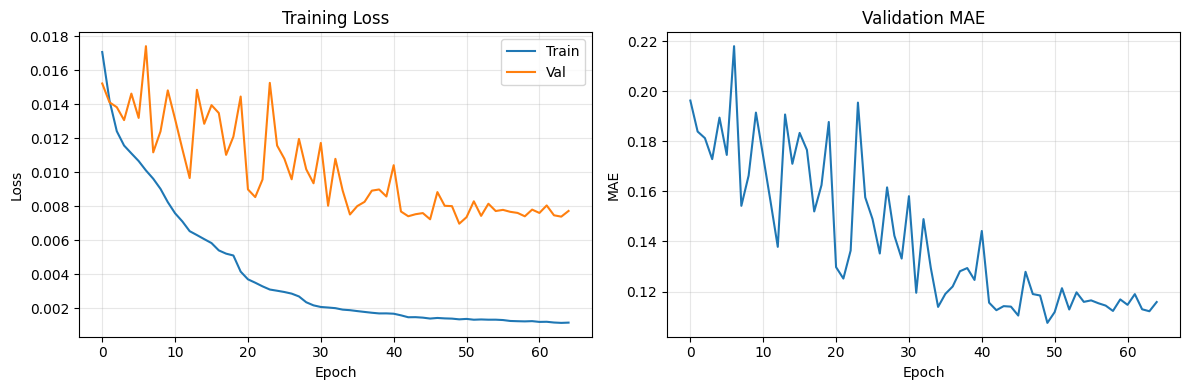

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_mae'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Validation MAE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()

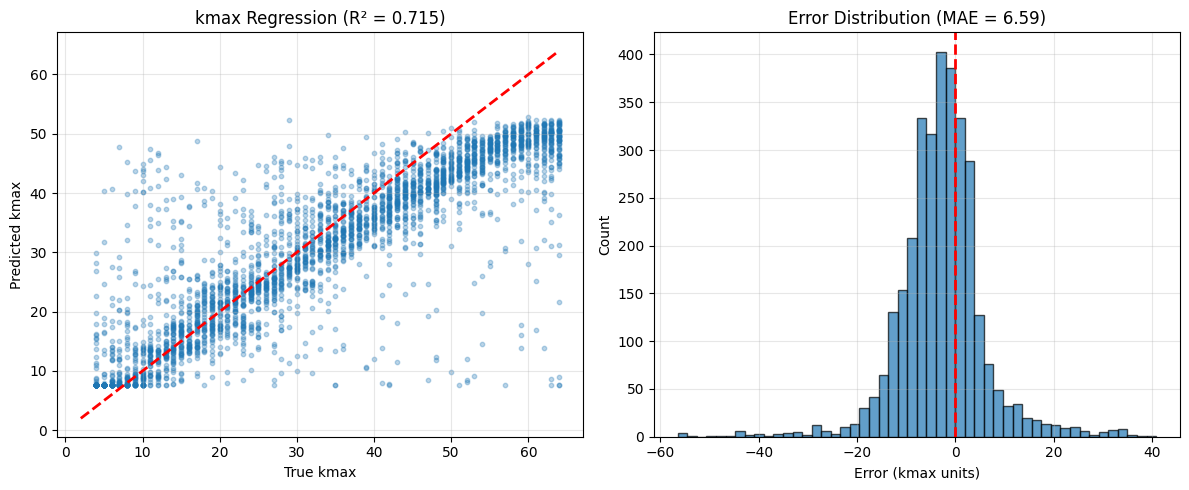

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0].plot([KMAX_MIN, KMAX_MAX], [KMAX_MIN, KMAX_MAX], 'r--', lw=2)
axes[0].set_xlabel('True kmax')
axes[0].set_ylabel('Predicted kmax')
axes[0].set_title(f'kmax Regression (R² = {r2:.3f})')
axes[0].grid(True, alpha=0.3)

errors = y_pred - y_true
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Error (kmax units)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Error Distribution (MAE = {mae:.2f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'predictions.png', dpi=150)
plt.show()

In [17]:
results = {
    'model': 'ResNet50_regression',
    'dataset': str(DATA_FILE.name),
    'metrics': {'mae': float(mae), 'rmse': float(rmse), 'r2': float(r2)},
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs_trained': len(history['train_loss']),
    },
    'training_time_minutes': train_time / 60
}

with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved to {OUTPUT_DIR}')

Saved to ..\..\outputs\kmax\regression
